Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [2]:
# The dataset to import images from
N_image = 1000
data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use
image_dataset = torchvision.datasets.ImageFolder(os.path.join(args.root, args.folders[0]), transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))
# dataloader = torch.utils.data.DataLoader(image_dataset, batch_size=1, shuffle=True, num_workers=1)
np.random.seed(args.seed)
idxs = np.random.permutation(len(image_dataset))[:N_image]

In [3]:
resolution = (128, 128)
resolution = (32, 32)
args.resolution = (64, 64)
size_ratio = 0.3 # how much of the image to use relative to radius


## doing the computations

In [4]:
for model_data_set_type in data_set_types: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    for model_name in ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [True, False]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')

            
            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)
            else:
                model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt'
                df_map = None
                if os.path.isfile(model_filename):
                    model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
                    
                    for i_image, idx in tqdm(enumerate(idxs)):
                        since = time.time()
                        full_image, label = image_dataset[idx]
                        ImageId = os.path.basename(image_dataset.samples[idx][0].split('.')[0])

                        full_image = full_image.squeeze(0)
                        full_image = full_image.to(device)

                        N_fixations = np.prod(resolution)
                        aspect_ratio = full_image.shape[1]/full_image.shape[2]
                        resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),
                                       int(np.sqrt(N_fixations/aspect_ratio)))

                        pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
                        args.image_size = box_size
                        args.do_polar = do_polar

                        pos_H, pos_W, outputs = compute_likelihood_map(args, model, full_image, resolution=resolution)
                        proba_label = outputs[:, label]

                        df_map_ = pd.DataFrame({'ImageId':image_dataset.samples[idx][0].split('Imagenet_full')[1], 'label':label, 'pos_H':[pos_H.astype(int).ravel()], 'pos_W':[pos_W.astype(int).ravel()], 'proba_label':[proba_label], 'time':time.time() - since})
                        if df_map is None:
                            df_map = df_map_
                        else:
                            df_map = pd.concat([df_map, df_map_], ignore_index=True)

                    df_map.to_parquet(df_filename)                        
                    print(25*'. ')
                else:
                    print(f' 😵‍💫 {model_filename} not found')
                    print(50*'-')
                    

model_data_set_type='full'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_name='resnet50'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_name='resnet101'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_data_set_type='bbox'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
......................................

In [6]:
annotations = get_annotation('csv')

df_results = pd.DataFrame([], columns=['model', 'image_name', 'likelihood_in_max', 'likelihood_out_max', 'distance', 'position_prior',
                                        'likelihood_in_mean', 'likelihood_out_mean', 'mid_point', 'in_point', 'ext_point',
                                        'Iou', 'label'])

for model_data_set_type in data_set_types: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    for model_name in ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [True, False]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')

            
            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)
                for i in np.linspace(0, len(df_map)-1, len(df_map), dtype = int):
                    image_name = df_map['ImageId'][0].split('/')[-1].split('.')[0]
                    ground_true_indices, three_points, ground_true = get_ground_true(args, image_name, annotations)

                    heatmap_numpy = df_map['proba_label'][i]
                    
                    mid_point, in_point, ext_point = get_like_point(heatmap_numpy, resolution, three_points)

                    arg_max_prior = np.argmax(heatmap_numpy)
                    position_prior = (arg_max_prior%args.resolution[0], arg_max_prior//args.resolution[1])
                    
                    
                    out_heat = np.delete(heatmap_numpy, [ground_true_indices[0]])
                    
                    likelihood_out_max = np.max(out_heat)
                    likelihood_in_max = np.max(heatmap_numpy[ground_true_indices[0]])
                
                    likelihood_out_mean = np.mean(out_heat)
                    likelihood_in_mean = np.mean(heatmap_numpy[ground_true_indices[0]])
                    
                
    
                    Iou = get_IoU(heatmap_numpy, ground_true.reshape(args.resolution[0]*args.resolution[1]))
                    
                    distance = int(euclidean_distance((round(args.resolution[0]/2), round(args.resolution[0]/2)), position_prior))

                    
                    df_results.loc[len(df_results)] = {'model':df_filename, 'image_name':image_name, 'likelihood_in_max': likelihood_in_max, 'likelihood_out_max': likelihood_out_max,
                                            'likelihood_out_mean': likelihood_out_mean, 'likelihood_in_mean': likelihood_in_mean, 'distance':distance,
                                             'mid_point':mid_point, 'in_point':in_point, 'ext_point':ext_point, 'Iou': Iou, 'position_prior':position_prior, 'label':labels[df_map['label'][i]]}
                    

model_data_set_type='full'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_name='resnet50'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_name='resnet101'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
..................................................
model_data_set_type='bbox'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=True
..................................................
args.do_polar=False
......................................

In [7]:
ind = 0
for model_data_set_type in data_set_types: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    for model_name in ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [True, False]:
            
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')

            
            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '_results_likelihood-maps.parquet'
            results = df_results[df_results['model']==df_filename]
            
            print(results['likelihood_in_mean'].mean(), 'likelihood_in_mean')
            print(results['likelihood_out_mean'].mean(), 'likelihood_out_mean')
            print(results['likelihood_in_mean'].mean()/results['likelihood_out_mean'].mean(), 'likelihood ratio')
            print(results['likelihood_in_max'].mean(), 'likelihood_in_max')
            print(results['likelihood_out_max'].mean(), 'likelihood_out_max')
            
            
            print(results['mid_point'].mean(), 'mid_point')
            print(results['in_point'].mean(), 'in_point')
            print(results['ext_point'].mean(), 'ext_point')
            

    
            mean_Iou = read_IoU(results['Iou'])
            
            
            
            inpel = 0
            for i, j in enumerate(results['likelihood_in_max']):
                #print(i, j, results['max_in_heat'][i] , '>', results['max_out_heat'][i])
                if results['likelihood_in_max'][i+ind] > results['likelihood_out_max'][i+ind]:
                    inpel += 1
            print(inpel/len(results['likelihood_in_max']), 'PG')
        
        
    #        dist = get_dist(results['dist'])
            print(results['in_point'].mean(), 'in_point')
            #print(dist[1].mean(), 'Distance moyenne 1')
            print(results['mid_point'].mean(), 'mid_point')
            #print(dist[2].mean(), 'Distance moyenne 2') 
            print(results['ext_point'].mean(), 'ext_point')

            ind += 1000
        


model_data_set_type='full'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=True
..................................................
0.0668551389017678 likelihood_in_mean
0.022332310496502923 likelihood_out_mean
2.9936507873753957 likelihood ratio
0.7496062942066346 likelihood_in_max
0.6657041680418769 likelihood_out_max
0.004808768723100508 mid_point
0.012679039311416809 in_point
0.001979573071078004 ext_point
{0: 0.25554343874954955, 1: 0.10045467566230841, 2: 0.08363159820146428, 3: 0.07418614194012146, 4: 0.06764986701848177, 5: 0.06250773700680136, 6: 0.05832845112187325, 7: 0.05471624972857894, 8: 0.05152818108420333, 9: 0.048539480130760926}
0.637 PG
0.012679039311416809 in_point
0.004808768723100508 mid_point
0.001979573071078004 ext_point
args.do_polar=False
..................................................
0.15909052223569242 likelihood_in_mean
0.056076124264262374 likelihood_out_mean
2.8

model_data_set_type='full'
--------------------------------------------------
model_name='resnet18'
..................................................
model_name='resnet50'
..................................................
model_name='resnet101'
..................................................
model_data_set_type='bbox'
--------------------------------------------------
model_name='resnet18'
..................................................
model_name='resnet50'
..................................................
model_name='resnet101'
..................................................
model_data_set_type='focus'
--------------------------------------------------
model_name='resnet18'
..................................................
model_name='resnet50'
..................................................
model_name='resnet101'
..................................................


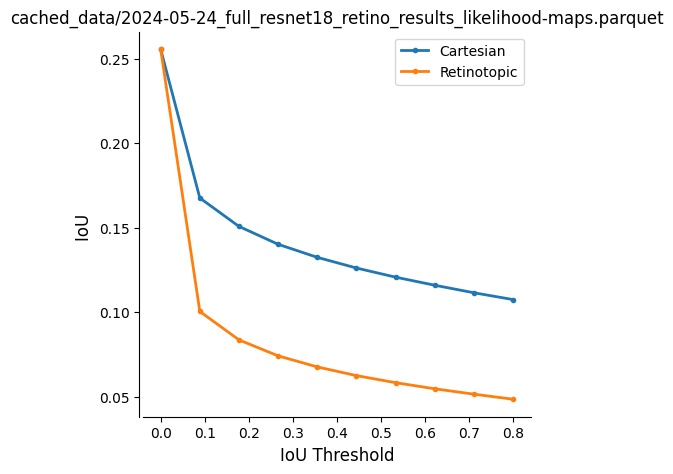

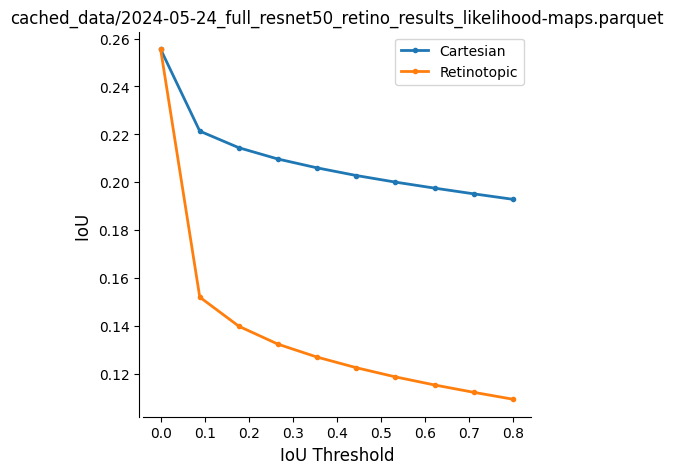

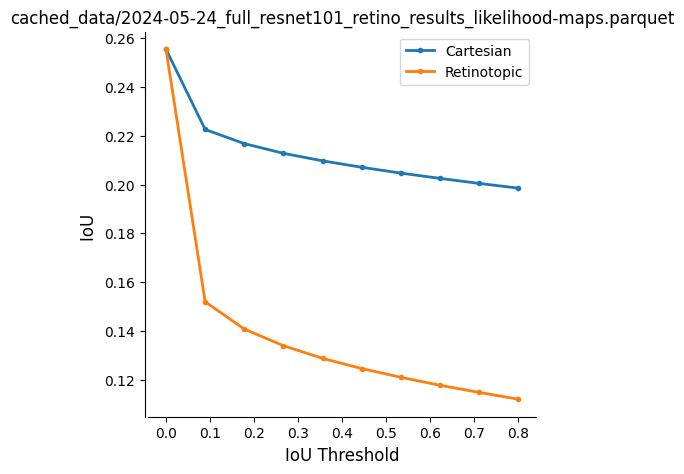

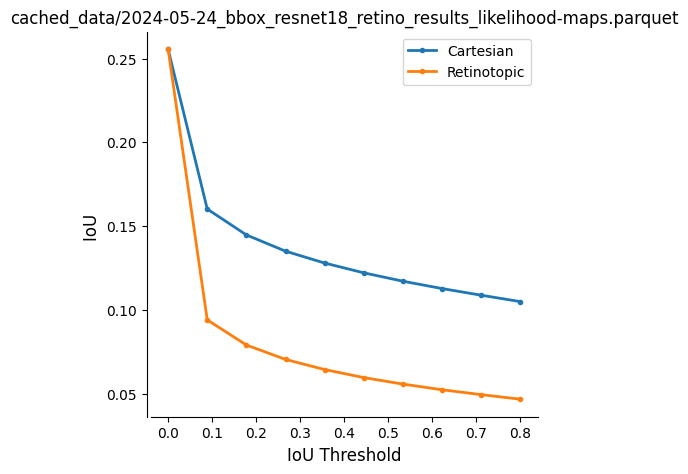

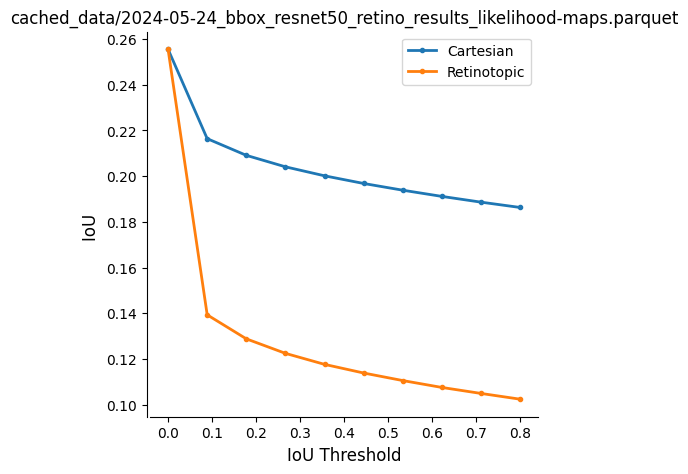

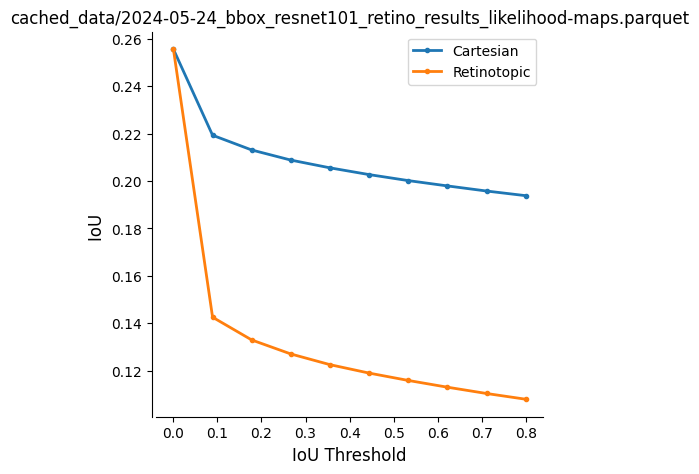

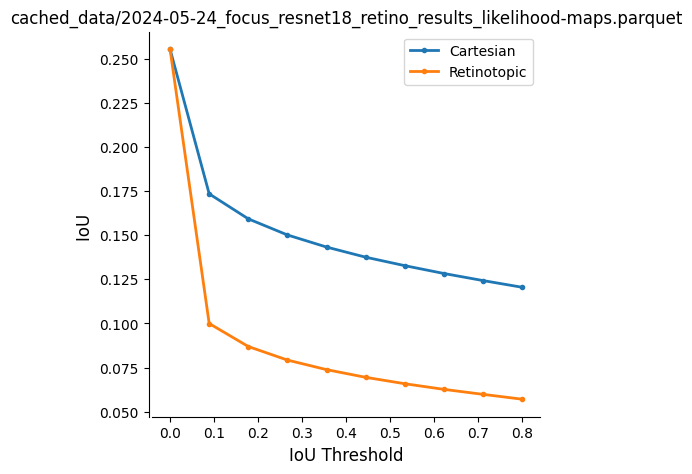

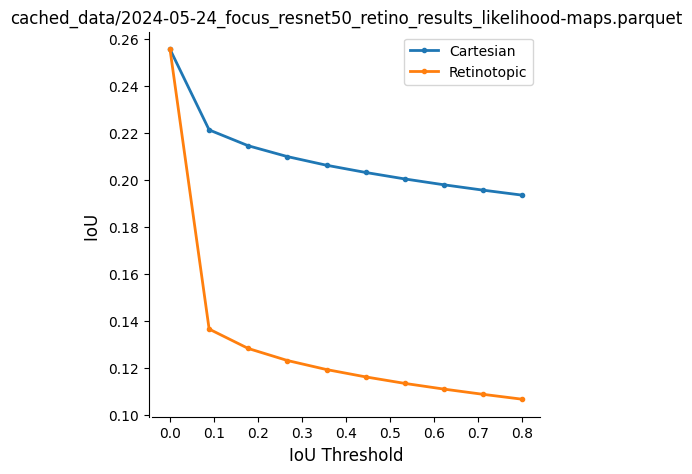

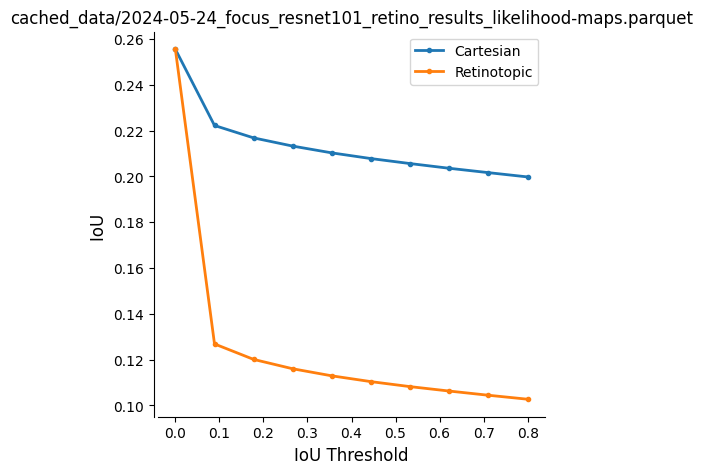

In [15]:


for model_data_set_type in data_set_types: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    for model_name in ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')
        
        dfs_ = {}
        GT = {}
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + '_results_likelihood-maps.parquet'
        df = df_results[df_results['model']==df_filename]
        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + '_results_likelihood-maps.parquet'
        df_ret = df_results[df_results['model']==df_filename]
        
        for df_, label in zip([df, df_ret], ['Cartesian', 'Retinotopic']):
        
            mean_Iou, list_Iou = read_IoU(df_['Iou'])
        
            ax.plot(np.linspace(0,.8,10), list_Iou, lw=2, marker='.', label=label)
            ax.set_xlabel(f"IoU Threshold", size=12)
            ax.set_ylabel(f"IoU ", size=12)
            ax.spines['left'].set_position(('axes', -0.01))
            #ax.set_yscale("logit", one_half="1/2", use_overline=True)
            ax.grid(which='both')
            ax.legend()
            ax.set_title(df_filename)
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);

model_data_set_type='full'
--------------------------------------------------
model_name='resnet18'
..................................................
model_name='resnet50'
..................................................
model_name='resnet101'
..................................................
model_data_set_type='bbox'
--------------------------------------------------
model_name='resnet18'
..................................................
model_name='resnet50'
..................................................
model_name='resnet101'
..................................................
model_data_set_type='focus'
--------------------------------------------------
model_name='resnet18'
..................................................
model_name='resnet50'
..................................................
model_name='resnet101'
..................................................


/tmp/ipykernel_1291/1304586031.py:28: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean())


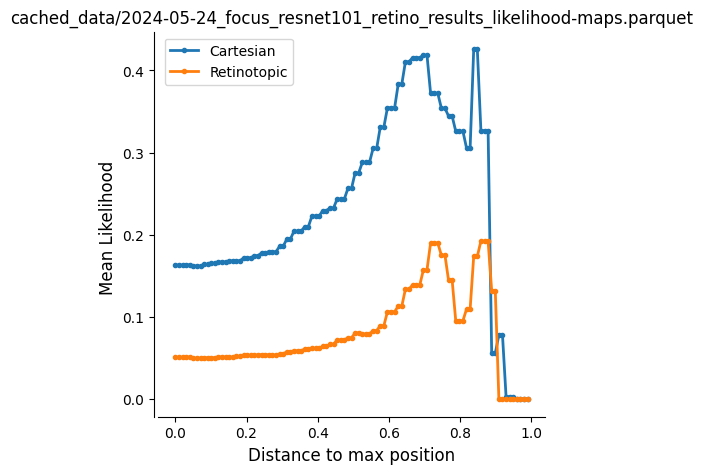

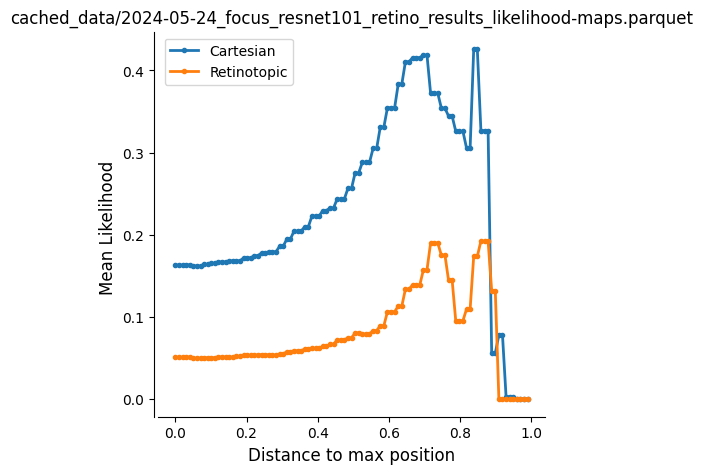

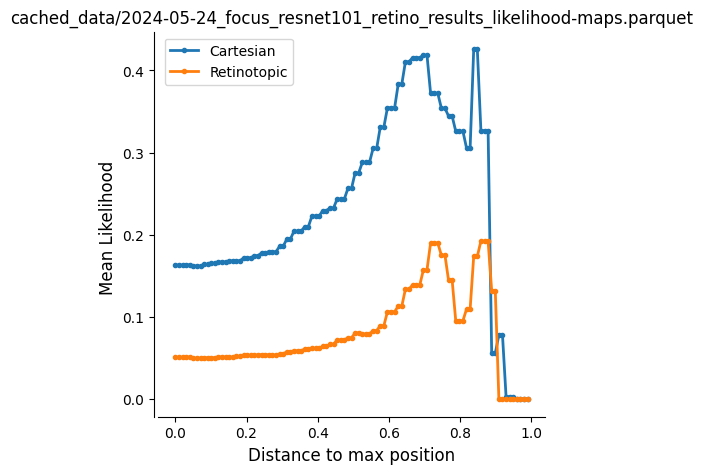

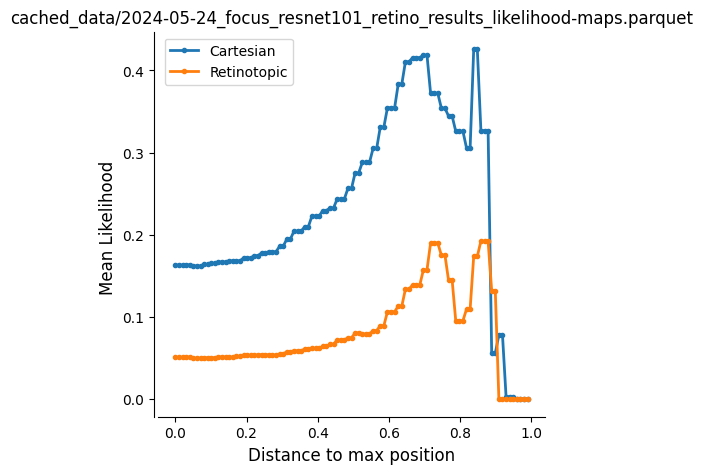

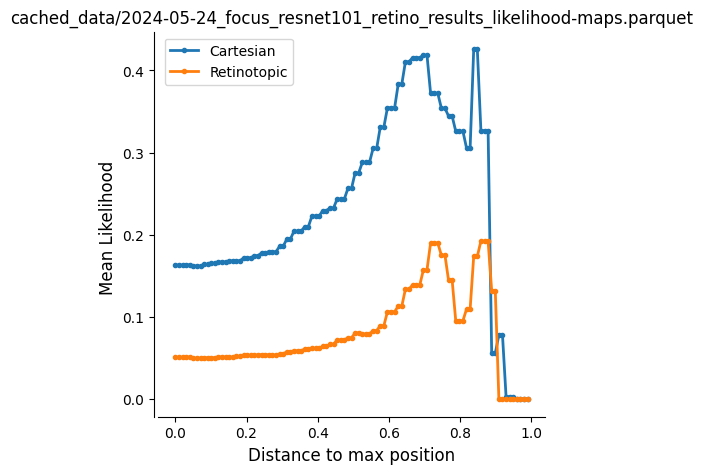

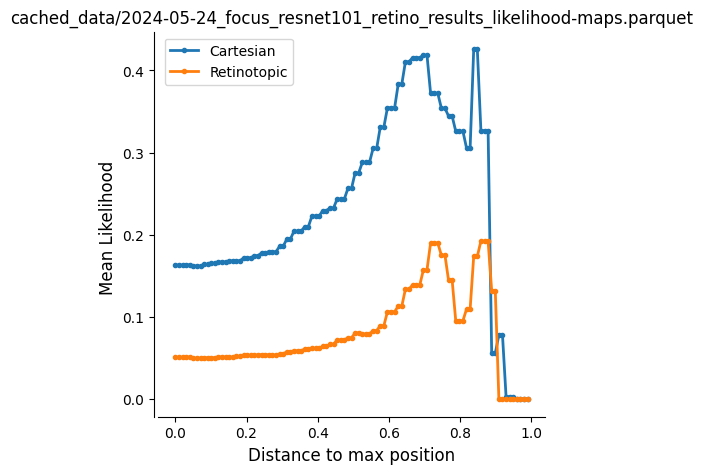

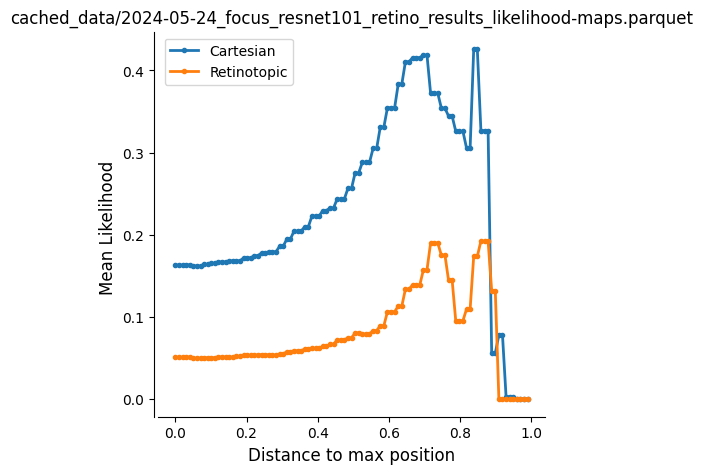

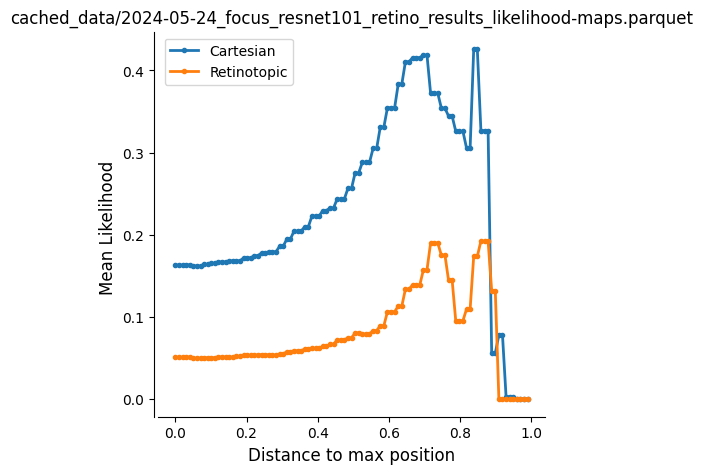

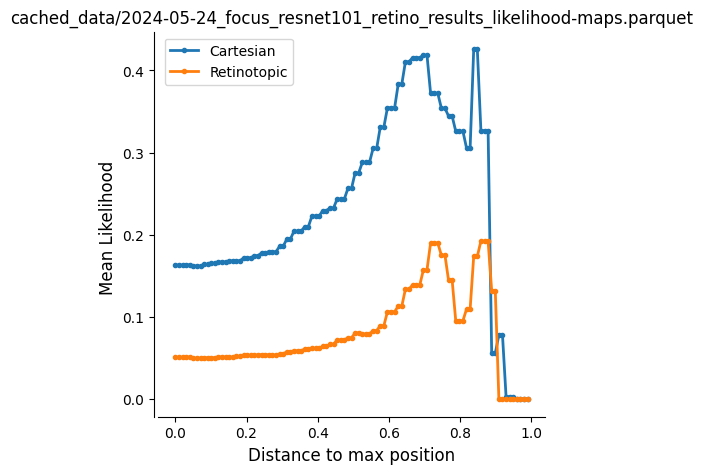

In [17]:

dist = np.array(results['distance'])

#distance_plot = np.concatenate(dist)
#distance_plot = normalize_array(dist)

for model_data_set_type in data_set_types: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    for model_name in ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        plt.tick_params(axis='both', which='major', labelsize=10)
        
        for df_, label in zip([ df, df_ret], ['Cartesian', 'Retinotopic']):
            list_dist = []
            
        
            likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['mid_point']), np.array(df_['ext_point'])])
            
            new_likelihood_plot = []
            for i in np.linspace(0, 1, 100 ):
                new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 
        
        
        
            ax.plot(np.linspace(0, 1, 100 ), new_likelihood_plot, lw=2, marker='.', label=label)
            ax.set_xlabel(f"Distance to max position", size=12)
            ax.set_ylabel(f"Mean Likelihood ", size=12)
            ax.spines['left'].set_position(('axes', -0.01))
        
            ax.grid(which='both')
            ax.legend()
            for side in ['top', 'right'] :ax.spines[side].set_visible(False)
            ax.set_title(df_filename)
            #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
            



In [ ]:
# from scipy.interpolate import UnivariateSpline

# for data_set_type in ['full']: # data_set_types:
#     print(50*'=')
#     print(f'{data_set_type=}')    

#     fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
#     # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
#     for model_name in ['resnet101', 'resnet50', 'resnet18']:
#         print(f'{model_name=}')    
#         print(50*'.')

#         for do_polar in [False, True]:
#             args.do_polar = do_polar
#             print(f'{args.do_polar=}')
#             print(50*'.')
#             df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_likelihood-maps.parquet'
#             if os.path.isfile(df_filename):
#                 df_map = pd.read_parquet(df_filename)

#                 ImageIds = df_map['ImageId'].unique()
#                 results = np.zeros((0, 2))
#                 for ImageId in ImageIds:
#                     df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
#                     pos_hotest = df_map_['proba_label'].argmax()
#                     distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
#                     distances_ /= distances_.max()
#                     results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
#                 # ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')

#                 x, y = results[:, 0], logit(results[:, 1])-logit(1/1000)
#                 idx_sort = np.argsort(x)
#                 x, y = x[idx_sort], y[idx_sort]
#                 # Calcul du lissage par spline
#                 spline = UnivariateSpline(x, y)
#                 xs = np.linspace(min(x), max(x), 1000)
#                 ys = spline(xs)
#                 ax.plot(xs, ys)

#                 ax.hlines(0, min(x), max(x), color='k', linestyle='--')
#         plt.show()


In [ ]:
# for data_set_type in ['full']: # data_set_types:
#     print(50*'=')
#     print(f'{data_set_type=}')    

#     fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
#     # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
#     for model_name in ['resnet101']:#, 'resnet50', 'resnet18']:
#         print(f'{model_name=}')    
#         print(50*'.')

#         for do_polar in [False, True]:
#             args.do_polar = do_polar
#             print(f'{args.do_polar=}')
#             print(50*'.')
#             df_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_likelihood-maps.parquet'
#             if os.path.isfile(df_filename):
#                 df_map = pd.read_parquet(df_filename)

#                 ImageIds = df_map['ImageId'].unique()
#                 results = np.zeros((0, 2))
#                 for ImageId in ImageIds:
#                     df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
#                     pos_hotest = df_map_['proba_label'].argmax()
#                     distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
#                     # print(np.median(distances_))
#                     distances_ /= np.median(distances_)
#                     # print(np.median(distances_))
#                     results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
#                 ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')
#                 ax.hlines(0, 0, 1, color='k', linestyle='--')
#         plt.show()


## reading localisation metadata

## doing the figure